## **DCGAN: Deep Convolutional Generative Adversarial Networks**

> **Este notebook roda no Kaggle** (usa os paths `/kaggle/input/...` e `/kaggle/working/...` do dataset [ai-face-dataset-3000-images](https://www.kaggle.com/datasets)). Abra-o diretamente lá, não no Colab.

Caso queira revisar a implementação veja esse post: [Understanding DCGANs: Deep Convolutional Generative Adversarial Networks
](https://medium.com/@danushidk507/understanding-dcgans-deep-convolutional-generative-adversarial-networks-1984bc028bf8)

**Roteiro (~1h):**

| Duração | Bloco |
|---|---|
| 10 min | Setup, distribuições de ruído, dados |
| 10 min | Gerador e Discriminador |
| 20 min | Treinamento (ou carregar checkpoint pronto — veja `LOAD_PRETRAINED` abaixo) |
| 15 min | Teste: treinar com uma distribuição, testar com outra |
| 5 min | Encerramento |

*Tarefa central*: Treinar e testar a GAN com districuições diferentes para Z~p(z). Vamos usar essas combinações:

| **$Z_{Train}$** | **$Z_{Test}$** |
| :-------------: | :------------: |
|      normal     |     uniform    |
|      normal     |     weibull    |
|     uniform     |     normal     |
|     uniform     |     weibull    |
|     weibull     |     normal     |
|     weibull     |     uniform    |
|      normal     |     uniform    |
|      normal     |     weibull    |
|     uniform     |     normal     |
|     uniform     |     weibull    |
|     weibull     |     normal     |
</cell id="cell-0">

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
import imageio.v2 as imageio

import time
import numpy as np
import os
from tqdm import tqdm

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

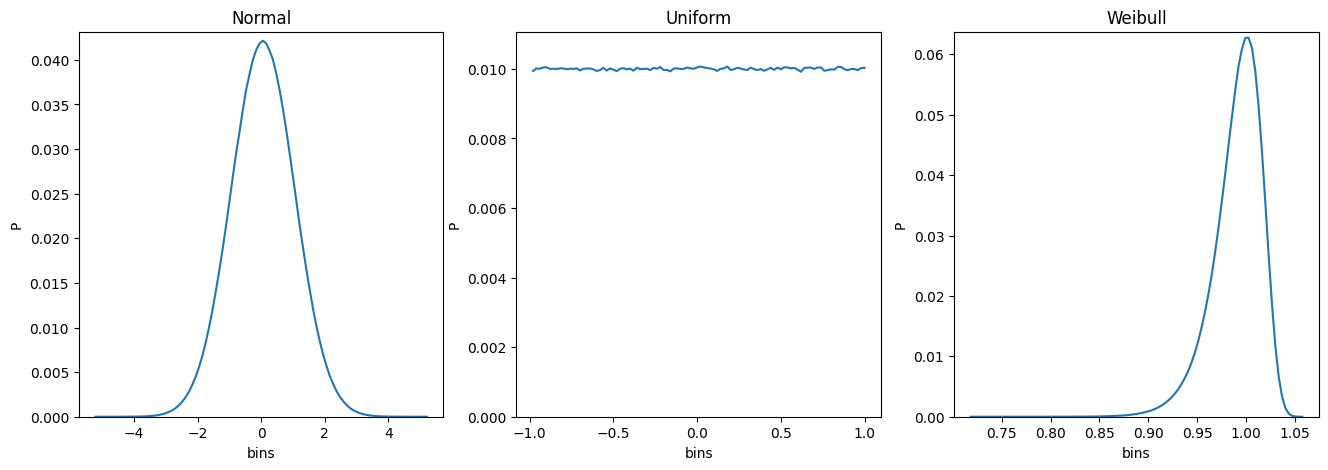

In [2]:
# Distributions
n = 10000000

d_normal , b_normal  = np.histogram(np.random.normal(0, 1, n), bins=100)
d_uniform, b_uniform = np.histogram(np.random.uniform(-1, 1, n), bins=100)
d_weibull, b_weibull = np.histogram(np.random.weibull(50, n), bins=100)

plt.figure(figsize=(16,5))
plt.subplot(1,3,1); plt.plot(b_normal[1:], d_normal/n)
plt.ylim([0, max(d_normal/n) + 1e-3])
plt.title('Normal')
plt.xlabel('bins'); plt.ylabel('P');

plt.subplot(1,3,2); plt.plot(b_uniform[1:], d_uniform/n)
plt.ylim([0, max(d_uniform/n) + 1e-3])
plt.title('Uniform')
plt.xlabel('bins'); plt.ylabel('P');

plt.subplot(1,3,3); plt.plot(b_weibull[1:], d_weibull/n)
plt.ylim([0, max(d_weibull/n) + 1e-3])
plt.title('Weibull')
plt.xlabel('bins'); plt.ylabel('P');

plt.show()

### Carregando e preparando os dados:

In [ ]:
# ==========================
# Hyperparameters
# ==========================
INPUT_SHAPE = 64
BATCH_SIZE = 32
EPOCHS = 30  # reduzido de 100 para caber numa aula de ~1h; suba para 100+ se rodar como pré-treino em background
LEAKY_SLOPE = 0.2
LR = 1e-4
LOSS = nn.BCELoss()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DISTRIBUTION_train = 'normal'
DISTRIBUTION_test  = 'weibull'

# ==========================
# Checkpoint pronto (pesos pré-treinados)
# ==========================
# LOAD_PRETRAINED = True  -> pula o treinamento e carrega os pesos prontos de CHECKPOINT_DIR
# LOAD_PRETRAINED = False -> treina do zero nesta sessão (EPOCHS acima)
#
# Os pesos prontos (generator_pretrained.pt / discriminator_pretrained.pt) foram treinados
# com ESTA MESMA arquitetura, com z ~ normal e dim(z) = INPUT_SHAPE = 64.
# No Kaggle: Add Input -> Datasets -> selecione o dataset com os pesos e ajuste CHECKPOINT_DIR
# para o path que aparecer em /kaggle/input/.
LOAD_PRETRAINED = False
CHECKPOINT_DIR = '/kaggle/input/dcgan-faces-pretrained'  # <--- ajuste para o dataset com os pesos

broken_files = ['seed111380.png', 'seed111370.png', 'seed111695.png']

# ==========================
# Dataset
# ==========================
class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.files = [f for f in os.listdir(dataset_dir) if not f.startswith('.') and f not in broken_files ]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        path = os.path.join(self.root_dir, fname)
        
        try:
            image = imageio.imread(path).astype(np.float32)
        except Exception as e:
            print(f"Warning: could not read {fname}, skipping. Error: {e}")
            
        image = (image - 127.5) / 127.5  # normalize to [-1, 1]

        # (H, W, C) → (C, H, W)
        image = torch.tensor(image).permute(2, 0, 1)
        image = self.transform(image)
                    
        return image

# ==========================
# Data Loading
# ==========================
dataset_dir = "/kaggle/input/ai-face-dataset-3000-images"  # <--- ajuste para seu path

transform = transforms.Compose([
    transforms.Resize((INPUT_SHAPE, INPUT_SHAPE)),  # resize to INPUT_SHAPExINPUT_SHAPE
])

dataset = ImageFolderDataset(dataset_dir,transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Dataset size: {len(dataset)} images")

# ==========================
# Visualização
# ==========================
def plot_image(img_tensor):
    """Exibe uma imagem normalizada."""
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = ((img + 1) * 127.5).astype(np.uint8)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Testar visualização
sample = next(iter(dataloader))[0]
print(f"Images shape: {sample.shape}")
plot_image(sample)

### Criando as redes Gerador e Discriminador

In [15]:
class Generator(nn.Module):
    def __init__(self, input_dim=128, leaky_slope=0.2):
        super(Generator, self).__init__()
        self.input_dim = input_dim
        self.leaky_slope = leaky_slope

        self.net = nn.Sequential(
            # FC: latent vector → feature map (4x4x1024)
            nn.Linear(input_dim, 1024 * 4 * 4),
            nn.LeakyReLU(leaky_slope, inplace=True),

            # reshape handled in forward()
            
            # 4x4 → 8x8
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),
            nn.Dropout(0.1),

            # 8x8 → 16x16
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),
            nn.Dropout(0.1),

            # 16x16 → 32x32
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),
            nn.Dropout(0.1),

            # 32x32 → 64x64
            nn.ConvTranspose2d(256, 3, kernel_size=4, stride=2, padding=1),
            # nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1),
            # nn.LeakyReLU(leaky_slope, inplace=True),
            # nn.Dropout(0.1),

            # # 64x64 → 128x128
            # nn.ConvTranspose2d(64, 3, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net[0](z)  # Linear
        x = self.net[1](x)  # LeakyReLU
        x = x.view(-1, 1024, 4, 4)  # Reshape latent → feature map
        x = self.net[2:](x)  # Pass through ConvTranspose blocks
        return x


# Example usage
device = "cuda" if torch.cuda.is_available() else "cpu"

generator = Generator(INPUT_SHAPE, LEAKY_SLOPE).to(device)
print(generator)

Generator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=16384, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Dropout(p=0.1, inplace=False)
    (5): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Dropout(p=0.1, inplace=False)
    (11): ConvTranspose2d(256, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (12): Tanh()
  )
)


In [33]:
# class Discriminator(nn.Module):
#     def __init__(self, leaky_slope=0.2):
#         super(Discriminator, self).__init__()
#         self.leaky_slope = leaky_slope

#         self.net = nn.Sequential(
#             # 128x128x3 → 64x64x64
#             nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
#             nn.LeakyReLU(leaky_slope, inplace=True),

#             # 64x64x64 → 32x32x128
#             nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
#             nn.LeakyReLU(leaky_slope, inplace=True),

#             # 32x32x128 → 16x16x256
#             nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
#             nn.LeakyReLU(leaky_slope, inplace=True),

#             # 16x16x256 → 8x8x512
#             nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
#             nn.LeakyReLU(leaky_slope, inplace=True),

#             nn.Flatten(),
#             nn.Linear(512 * 8 * 8, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, leaky_slope=0.2):
        super(Discriminator, self).__init__()
        self.leaky_slope = leaky_slope

        self.net = nn.Sequential(
            # 64x64x3 → 32x32x64
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),

            # 32x32x64 → 16x16x128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),

            # 16x16x128 → 8x8x256
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),

            # 8x8x256 → 4x4x512
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(leaky_slope, inplace=True),

            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


LEAKY_SLOPE = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"

discriminator = Discriminator(LEAKY_SLOPE).to(device)
print(discriminator)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=8192, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


### Criando a GAN

In [40]:
class GAN(nn.Module):
    def __init__(self, generator, discriminator):
        super(GAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator

    def forward(self, z):
        # Generate fake images
        fake_imgs = self.generator(z)
        # Evaluate with discriminator
        validity = self.discriminator(fake_imgs)
        return validity

In [41]:

# Create models
generator = Generator(INPUT_SHAPE, LEAKY_SLOPE).to(device)
discriminator = Discriminator(LEAKY_SLOPE).to(device)

# Loss
criterion = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

# Create GAN wrapper (optional)
gan = GAN(generator, discriminator).to(device)

In [42]:
def rand_vector(distribution, size, device="cpu"):
    """
    Generate random latent vectors.
    """
    if distribution == "normal":
        return torch.randn(size, device=device)
    elif distribution == "uniform":
        return (torch.rand(size, device=device) * 2 - 1)
    elif distribution == "weibull":
        q = torch.from_numpy(np.random.weibull(50, size)).float().to(device)
        q = (q - q.mean()) / q.std()
        return q
    else:
        raise ValueError("Specify a valid distribution: normal, uniform, weibull")


def plot_generated_images(id, generator, input_dist, samples=9, dim=(3,3), figsize=(5,5), device="cpu"):
    # Generate latent vectors
    z = rand_vector(input_dist, (samples, INPUT_SHAPE), device=device)
    
    # Generate images
    generator.eval()
    with torch.no_grad():
        generated_images = generator(z)
    
    # Rescale from [-1,1] → [0,255] and convert to numpy
    images = ((generated_images + 1) * 127.5).clamp(0, 255).cpu().numpy().astype('uint8')
    
    # images shape: (samples, 3, 128, 128) → transpose to (samples, 128,128,3)
    images = images.transpose(0, 2, 3, 1)
    
    # Plot
    plt.figure(figsize=figsize)
    for i in range(samples):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir + f'GAN_image_{id}.png')
    plt.show()

#### Passos de treinamento

Em cada batch:

1. **Treinar o discriminador**

   * Gerar previsões de imagens falsas a partir do gerador
   * A referência é **1 para imagens reais** e **0 para imagens falsas**
   * Treinar o discriminador (**com o gerador congelado**)

2. **Treinar o gerador**

   * Congelar os pesos do discriminador
   * O modelo "gan" produz imagens falsas a partir de ruído aleatório e obtém a saída do discriminador. Treinar o modelo "gan" com o discriminador congelado
   * A referência é **1 para as imagens falsas** (ou seja, enganar o discriminador)

> Se `LOAD_PRETRAINED = True` (definido lá em cima), a célula abaixo pula o treinamento inteiro e a seção de Teste carrega os pesos prontos de `CHECKPOINT_DIR` — use isso se o tempo da aula acabar antes do treino convergir.

In [ ]:
output_dir = '/kaggle/working/'
# Ensure output dir exists
os.makedirs(output_dir, exist_ok=True)

d_loss_history = []
g_loss_history = []
saved_epochs = []  # controla quais épocas têm checkpoint salvo, para carregar a mais recente depois

start_time = time.time()

if not LOAD_PRETRAINED:
    for e in range(1, EPOCHS+1):
        for i, real_batch in enumerate(dataloader):
            batch_size = real_batch.size(0)
            real_batch = real_batch.to(device)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            discriminator.train()
            generator.eval()

            # Labels with random noise (label smoothing)
            real_labels = torch.ones(batch_size, 1, device=device) - 0.05 * torch.rand(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device) + 0.05 * torch.rand(batch_size, 1, device=device)

            # Generate fake images
            z = rand_vector(DISTRIBUTION_train, (batch_size, INPUT_SHAPE), device=device)
            fake_batch = generator(z)

            # Concatenate and shuffle
            all_imgs = torch.cat([real_batch, fake_batch], dim=0)
            all_labels = torch.cat([real_labels, fake_labels], dim=0)
            idx = torch.randperm(all_imgs.size(0))
            all_imgs = all_imgs[idx][:batch_size]
            all_labels = all_labels[idx][:batch_size]

            optimizer_D.zero_grad()
            d_output = discriminator(all_imgs)
            d_loss = criterion(d_output, all_labels)
            d_loss.backward()
            optimizer_D.step()

            # -----------------
            #  Train Generator
            # -----------------
            discriminator.eval()
            generator.train()
            for p in discriminator.parameters():
                p.requires_grad = False  # freeze discriminator

            z = rand_vector(DISTRIBUTION_train, (batch_size, INPUT_SHAPE), device=device)
            optimizer_G.zero_grad()
            g_output = discriminator(generator(z))
            g_loss = criterion(g_output, torch.ones(batch_size, 1, device=device))
            g_loss.backward()
            optimizer_G.step()

            for p in discriminator.parameters():
                p.requires_grad = True  # unfreeze

        # Record losses
        d_loss_history.append(d_loss.item())
        g_loss_history.append(g_loss.item())

        # Print epoch info
        print(f"Epoch: {e}, Time: {time.time() - start_time:.2f}s, g_loss: {g_loss.item():.4f}, d_loss: {d_loss.item():.4f}")

        # Plot generated images every 10 epochs
        if e == 1 or e % 10 == 0:
            torch.save(generator.state_dict(), os.path.join(output_dir, f'generator_epoch{e}.pt'))
            torch.save(discriminator.state_dict(), os.path.join(output_dir, f'discriminator_epoch{e}.pt'))
            saved_epochs.append(e)
            plot_generated_images(str(e), generator, DISTRIBUTION_train, device=device)

            # Plot learning curves
            plt.figure(figsize=(6,5))
            plt.plot(np.arange(len(d_loss_history)), d_loss_history, color='blue', label='Discriminator')
            plt.plot(np.arange(len(g_loss_history)), g_loss_history, color='red', label='Generator')
            plt.legend()
            plt.grid(True)
            plt.title('Learning curves')
            plt.ylabel('Loss')
            plt.xlabel('Epochs')
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, "Learning_curves.png"), dpi=500)
            plt.close()
else:
    print("LOAD_PRETRAINED=True: pulando o treinamento, vá direto para a seção de Teste.")

### Teste

In [ ]:
import glob, re

generator = Generator(INPUT_SHAPE, LEAKY_SLOPE).to(device)

if LOAD_PRETRAINED:
    # pesos prontos, treinados com antecedência (ver CHECKPOINT_DIR lá em cima)
    ckpt_path = os.path.join(CHECKPOINT_DIR, 'generator_pretrained.pt')
    if not os.path.exists(ckpt_path):
        # aceita também checkpoints nomeados por época; pega a época mais alta
        cands = glob.glob(os.path.join(CHECKPOINT_DIR, 'generator_epoch*.pt'))
        if not cands:
            raise FileNotFoundError(
                f"Nenhum checkpoint de gerador em {CHECKPOINT_DIR}. "
                "Anexe o dataset com os pesos (Add Input) ou use LOAD_PRETRAINED = False."
            )
        ckpt_path = max(cands, key=lambda p: int(re.search(r'epoch(\d+)', p).group(1)))
else:
    # usa o checkpoint mais recente salvo durante o treino desta sessão
    # (corrigido: antes carregava 'discriminator_epoch1.pt' dentro do generator por engano)
    ultima_epoca_salva = saved_epochs[-1]
    ckpt_path = os.path.join(output_dir, f'generator_epoch{ultima_epoca_salva}.pt')

print(f'Carregando pesos de: {ckpt_path}')
generator.load_state_dict(torch.load(ckpt_path, map_location=device))
generator.eval()

In [ ]:
# Generate images with training distribution
plot_generated_images(
    f'Tr_{DISTRIBUTION_train}---Ts_{DISTRIBUTION_train}',
    generator,
    DISTRIBUTION_train,
    samples=16,
    dim=(4,4),
    figsize=(6,6),
    device=device
)

# Generate images with test distribution
plot_generated_images(
    f'Tr_{DISTRIBUTION_train}---Ts_{DISTRIBUTION_test}',
    generator,
    DISTRIBUTION_test,
    samples=16,
    dim=(4,4),
    figsize=(6,6),
    device=device
)

### Evolução do gerador ao longo do treino

Cada checkpoint é um retrato do gerador numa época. Carregando vários deles e gerando
**sempre a partir do mesmo `z`**, dá para ver a mesma "identidade" saindo de um borrão
colorido até virar um rosto — cada linha da figura é uma época, cada coluna é um `z` fixo.

Com `LOAD_PRETRAINED = True` isso usa os checkpoints prontos de `CHECKPOINT_DIR`; com
`False`, usa os que o seu próprio treino salvou em `output_dir`.

In [ ]:
import glob, re

# De onde vêm os checkpoints: os prontos, ou os salvos pelo treino desta sessão
ckpt_dir = CHECKPOINT_DIR if LOAD_PRETRAINED else output_dir

def checkpoints_disponiveis(d):
    """[(época, path), ...] ordenado por época."""
    achados = []
    for p in glob.glob(os.path.join(d, 'generator_epoch*.pt')):
        m = re.search(r'epoch(\d+)\.pt$', p)
        if m:
            achados.append((int(m.group(1)), p))
    return sorted(achados)

ckpts = checkpoints_disponiveis(ckpt_dir)
print(f'{len(ckpts)} checkpoints em {ckpt_dir}: épocas {[e for e, _ in ckpts]}')

if not ckpts:
    print('Nenhum checkpoint por época encontrado — treine com LOAD_PRETRAINED = False '
          'ou anexe o dataset com os pesos prontos.')
else:
    N_COLS = 6

    # mesmo z para todas as épocas: o que muda na figura é só o gerador
    torch.manual_seed(0)
    np.random.seed(0)
    z_fixo = rand_vector(DISTRIBUTION_train, (N_COLS, INPUT_SHAPE), device=device)

    g_tmp = Generator(INPUT_SHAPE, LEAKY_SLOPE).to(device)

    fig, axes = plt.subplots(len(ckpts), N_COLS,
                             figsize=(N_COLS * 1.5, len(ckpts) * 1.6),
                             squeeze=False)

    for linha, (epoca, path) in enumerate(ckpts):
        g_tmp.load_state_dict(torch.load(path, map_location=device))
        g_tmp.eval()
        with torch.no_grad():
            imgs = g_tmp(z_fixo)
        imgs = ((imgs + 1) * 127.5).clamp(0, 255).cpu().numpy().astype('uint8').transpose(0, 2, 3, 1)

        for col in range(N_COLS):
            axes[linha][col].imshow(imgs[col])
            axes[linha][col].axis('off')
        # rótulo da linha (axis('off') apaga o ylabel, por isso um text)
        axes[linha][0].text(-0.12, 0.5, f'época {epoca}',
                            transform=axes[linha][0].transAxes,
                            ha='right', va='center', fontsize=11)

    plt.suptitle(f'Evolução do gerador — mesmo z ~ {DISTRIBUTION_train}')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'evolucao_checkpoints.png'),
                dpi=120, bbox_inches='tight')
    plt.show()

## Tarefa opcional

Enquanto esperamos o modelo treinar, implemente uma conditional GAN básica em pytorch. Você pode seguir o tutorial "[Rede Adversarial Generativa Condicional
](https://www.geeksforgeeks.org/deep-learning/conditional-generative-adversarial-network/)" (que usa tensorflow). Recomendo usar LLM para ajudar na "tradução" caso caia num impasse.  